In [1]:
!pip install ultralytics -q
!pip install paddlepaddle==3.0.0 -q
!pip install paddleocr -q
!pip install langchain_text_splitters -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.9/192.9 MB 8.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.7/80.7 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.8/120.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 31.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 25.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 101.4 MB/s eta 0:00:0000:01
   ━━━

In [1]:
import os
import cv2
import torch
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torchvision.io import read_image
import matplotlib.patches as patches
from pathlib import Path
from glob import glob
import shutil
import yaml

from ultralytics import YOLO

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [2]:
import zipfile

with zipfile.ZipFile("lenta_dataset.zip", "r") as zip_ref:
    zip_ref.extractall("lenta_dataset")

In [3]:
df1 = pd.read_csv('lenta_dataset/25_12-20/25_12-20.csv')
df2 = pd.read_csv('lenta_dataset/26_12-20/26_12-20.csv')
df3 = pd.read_csv('lenta_dataset/43_15/43_15.csv')

In [4]:
for c1, c2, c3 in zip(df1.columns, df2.columns, df3.columns):
    if c1 != c2 or c1!=c3 or c2!=c3:
        print("Не совпадает:")
        print("df1:", repr(c1))
        print("df2:", repr(c2))
        print("df3:", repr(c3))

Не совпадает:
df1: 'wholesale_level_1_count'
df2: 'wholesale_level_1_coun'
df3: 'wholesale_level_1_coun'


In [5]:
df3.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)
df2.rename(columns={'wholesale_level_1_coun':'wholesale_level_1_count'}, inplace=True)

In [6]:
df1.columns

Index(['filename', 'product_name', 'price_default', 'price_card',
       'price_discount', 'barcode', 'discount_amount', 'id_sku',
       'print_datetime', 'code', 'additional_info', 'color', 'special_symbols',
       'frame_timestamp', 'x_min', 'y_min', 'x_max', 'y_max',
       'qr_code_barcode', 'price1_qr', 'price2_qr', 'price3_qr', 'price4_qr',
       'wholesale_level_1_count', 'wholesale_level_1_price',
       'wholesale_level_2_count', 'wholesale_level_2_price', 'action_price_qr',
       'action_code_qr'],
      dtype='object')

In [7]:
type(df1["frame_timestamp"].iloc[0])

numpy.int64

In [8]:
df1['filename'].unique()[0]

'25_12-20/2.mp4'

In [9]:
def clean_video_name(x):
    x = str(x).strip()          
    x = x.split("/")[0]        
    if not x.endswith(".mp4"):
        x += ".mp4"
    return x

dfs = [df1, df2, df3]

for df in dfs:
    df["filename"] = df["filename"].apply(clean_video_name)

df1['filename'].unique()[0]

'25_12-20.mp4'

In [10]:
root_dir = Path("lenta_dataset")
out_dir = Path("all_frames")
out_dir.mkdir(exist_ok=True)

dfs = [df1, df2, df3]

for df in dfs:
    df = df.copy()
    df["frame_timestamp"] = df["frame_timestamp"].astype(float)

    video_name = Path(str(df["filename"].iloc[0])).stem
    video_path = root_dir / video_name / f"{video_name}.mp4"

    print("Обрабатываю:", video_name)

    cap = cv2.VideoCapture(str(video_path))
    fps = cap.get(cv2.CAP_PROP_FPS)

    times = sorted(df["frame_timestamp"].drop_duplicates())
    target_frames = {
        int(round(t * fps / 1000)): int(t)
        for t in times
    }

    print("Нужно кадров:", len(target_frames))

    save_dir = out_dir / video_name
    save_dir.mkdir(exist_ok=True)

    current_frame = 0
    saved = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if current_frame in target_frames:
            t = target_frames[current_frame]

            filename = save_dir / f"{t}.jpg"
            cv2.imwrite(str(filename), frame)

            saved += 1

        current_frame += 1

    cap.release()

    print("Сохранено:", saved)

Обрабатываю: 25_12-20
Нужно кадров: 10
Сохранено: 10
Обрабатываю: 26_12-20
Нужно кадров: 15
Сохранено: 15
Обрабатываю: 43_15
Нужно кадров: 2
Сохранено: 2


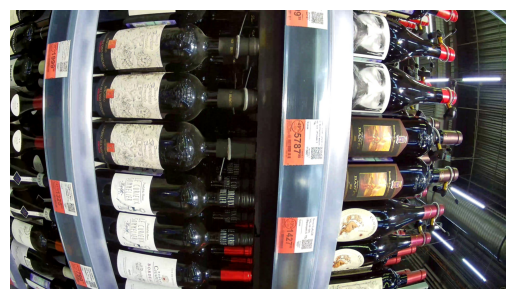

In [12]:
img = cv2.imread('all_frames/26_12-20/27156.jpg')
plt.axis('off')
plt.imshow(img[:, :, ::-1]);

In [14]:
df = pd.concat([df1, df2, df3], ignore_index = True)

In [25]:
cols = ['x_min', 'y_min', 'x_max', 'y_max']

df[cols] = df.apply(
    lambda row: pd.Series(
        [float(str(row[c]).replace(",", ".")) for c in cols],
        index=cols
    ),
    axis=1
)

In [15]:
df["img_path"] = df.apply(
    lambda row: str(
        out_dir /
        Path(row["filename"]).stem /
        f"{int(row['frame_timestamp'])}.jpg"
    ),
    axis=1
)
df.head()

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,price2_qr,price3_qr,price4_qr,wholesale_level_1_count,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr,img_path
0,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63","129,99",нет,4670025474665,-48%,270207736530,03.04.2026 3:08,нет,...,239.99,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
1,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63","129,99",нет,4670025474658,-48%,270207736529,03.04.2026 3:08,нет,...,239.99,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
2,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99","129,99",нет,4680140271438,-10%,270207716055,04.04.2026 1:09,нет,...,137.79,нет,129.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg
3,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99","129,99",нет,4680140271469,-10%,270207716056,04.04.2026 1:09,024 017_1_6_2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,all_frames\25_12-20\0.jpg
4,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36","259,99",нет,4630027300508,-52%,270207659437,17.03.2026 13:27,нет,...,519.99,нет,259.99,нет,нет,нет,нет,нет,нет,all_frames\25_12-20\5745.jpg


In [27]:
def visualize_from_df(df, img_path):

    sub = df[df["img_path"] == img_path]

    img = cv2.imread(img_path)
    img = img[:, :, ::-1]  

    fig, ax = plt.subplots(1, figsize=(10, 6))
    ax.imshow(img)

    for _, row in sub.iterrows():
        xmin = int(row["x_min"])
        ymin = int(row["y_min"])
        xmax = int(row["x_max"])
        ymax = int(row["y_max"])

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=2,
            edgecolor='red',
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.scatter(xmin, ymin, color='white', s=10)
        ax.scatter(xmax, ymax, color='white', s=10)

    ax.axis("off")
    plt.show()

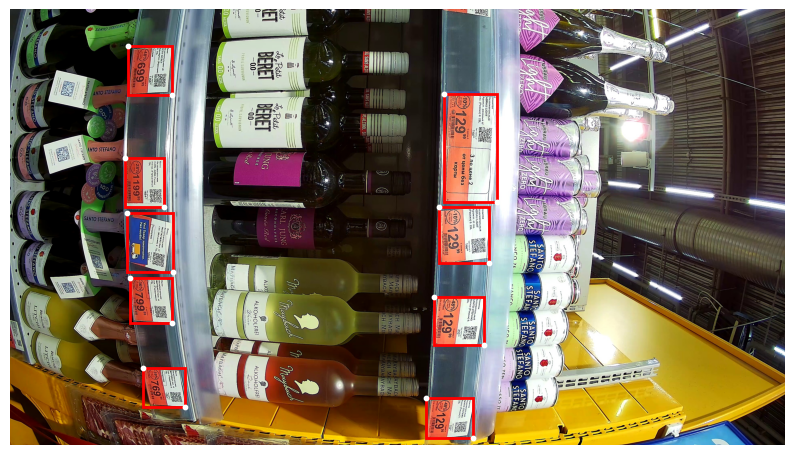

In [16]:
img_paths = df["img_path"].unique()

visualize_from_df(df, img_paths[0])

In [46]:
# crop = img[y1:y2, x1:x2]
# plt.axis('off')
# plt.imshow(crop[:, :, ::-1]);
# #plt.savefig('crop.jpg')

In [47]:
# rotated = cv2.rotate(crop, cv2.ROTATE_90_COUNTERCLOCKWISE)
# plt.axis("off")
# plt.imshow(rotated[:, :, ::-1]);
# #plt.savefig('crop.jpg')

In [17]:
def pascal_voc_to_yolo_boxes(image, xmin, ymin, xmax, ymax):
    _, height, width = image.shape
    h = [ymax+ymin, ymax-ymin]
    w = [xmax+xmin, xmax-xmin]
    x_center = w[0]/2
    y_center = h[0]/2
    
    x_center_norm = x_center/width
    y_center_norm =  y_center/height
    width_norm = w[1]/width
    height_norm = h[1]/height
    yolo_bbox = [x_center_norm, y_center_norm, width_norm, height_norm]
    
    return yolo_bbox

In [28]:
def process_row(row):
    path = row['img_path']
    if not Path(path).exists():
        return None, None, None, None
    img = read_image(path)
    return pascal_voc_to_yolo_boxes(img, row.x_min, row.y_min, row.x_max, row.y_max)

results = df.apply(process_row, axis=1)
df[['x_c', 'y_c', 'w', 'h']] = pd.DataFrame(results.tolist(), index=df.index)

In [29]:
df.head()

,filename,product_name,price_default,price_card,price_discount,barcode,discount_amount,id_sku,print_datetime,code,...,wholesale_level_1_price,wholesale_level_2_count,wholesale_level_2_price,action_price_qr,action_code_qr,img_path,x_c,y_c,w,h
0,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Rosso (Ро...,"252,63","129,99",нет,4670025474665,-48%,270207736530,03.04.2026 3:08,нет,...,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg,0.567669,0.938866,0.060807,0.090880
1,25_12-20.mp4,Напиток безалкогольный SANTO STEFANO Bianco (Р...,"252,63","129,99",нет,4670025474658,-48%,270207736529,03.04.2026 3:08,нет,...,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg,0.579102,0.715718,0.065078,0.108750
2,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. с/г...,"144,99","129,99",нет,4680140271438,-10%,270207716055,04.04.2026 1:09,нет,...,нет,нет,нет,нет,нет,all_frames\25_12-20\0.jpg,0.585833,0.517917,0.064844,0.129259
3,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Аромат. роз...,"144,99","129,99",нет,4680140271469,-10%,270207716056,04.04.2026 1:09,024 017_1_6_2,...,NaN,NaN,NaN,NaN,NaN,all_frames\25_12-20\0.jpg,0.593815,0.318565,0.068880,0.249167
4,25_12-20.mp4,Напиток безалкогольный ABRAU LIGHT Zero аромат...,"547,36","259,99",нет,4630027300508,-52%,270207659437,17.03.2026 13:27,нет,...,нет,нет,нет,нет,нет,all_frames\25_12-20\5745.jpg,0.567474,0.925347,0.061354,0.095139


In [30]:
def enable_determinism():
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    torch.use_deterministic_algorithms(True)

def fix_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.mps.manual_seed(seed)


enable_determinism()
fix_seeds(24)

In [32]:
def visualize_yolo_bbox(image_np, bbox):
    print('YOLO формат\n(x_center_normalize, y_center_normalize, width_normalize, height_normalize)')
    print('bbox:\n', bbox)
    fig, ax = plt.subplots(1)
    ax.imshow(image_np)

    h, w, _ = image_np.shape
    x_center, y_center, width, height = bbox

    # Преобразуем нормализованные координаты в пиксели
    x_center_pix = x_center * w
    y_center_pix = y_center * h
    width_pix = width * w
    height_pix = height * h

    xmin = int(x_center_pix - width_pix / 2)
    ymin = int(y_center_pix - height_pix / 2)
    xmax = int(x_center_pix + width_pix / 2)
    ymax = int(y_center_pix + height_pix / 2)

    rect = patches.Rectangle((xmin, ymin), width_pix, height_pix, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)


    # Визуализируем центр
    ax.scatter(x_center_pix, y_center_pix, color='white', s=10, marker='o')
    plt.text(x_center_pix + 5, y_center_pix, f'({round(x_center,2)}, {round(y_center,2)})', fontsize=10, color='white', ha='right', va='bottom')

    plt.text(x_center_pix - 30, ymax + 15, f"Width: {width:.2f}", color='white', fontsize=10)
    plt.text(xmax + 15, y_center_pix, f"Height: {height:.2f}", color='white', fontsize=10)

    # Устанавливаем относительные оси от 0 до 1
    ax.set_xticks(np.linspace(0, w, num=9))  # 6 меток по оси X
    ax.set_yticks(np.linspace(0, h, num=10))  # 6 меток по оси Y

    ax.set_xticklabels(np.linspace(0, 1, num=9), rotation=0)
    ax.set_yticklabels(np.round(np.linspace(0, 1, num=10), 2))  # Переворот для правильного отображения Y
    ax.xaxis.set_ticks_position('top')
    ax.xaxis.set_label_position('top')
    plt.show()

YOLO формат
(x_center_normalize, y_center_normalize, width_normalize, height_normalize)
bbox:
 x_c    0.567669
y_c    0.938866
w      0.060807
h      0.090880
Name: 0, dtype: float64


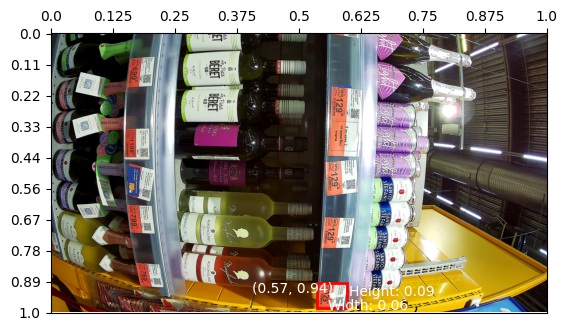

In [33]:
img = cv2.imread(df['img_path'].iloc[0])
bbox = df[['x_c', 'y_c', 'w', 'h']].iloc[0]
visualize_yolo_bbox(img[:, :, ::-1], bbox)

In [34]:
unique_images = df['img_path'].unique() 
np.random.shuffle(unique_images)
 
val_size = int(0.2 * len(unique_images))
val_images = set(unique_images[:val_size])
train_images = set(unique_images[val_size:])
 
df_train = df[df['img_path'].isin(train_images)]
df_val = df[df['img_path'].isin(val_images)]
 
print(f"Train images: {len(train_images)}")
print(f"Val images:   {len(val_images)}")

Train images: 22
Val images:   5


In [35]:
def create_dataset_template(path_to_create_dataset_template):
    new_dataset_path = Path(path_to_create_dataset_template)
    new_dataset_path.mkdir(exist_ok=True)
    
    path_to_train_images = Path(new_dataset_path, 'images', 'train')
    path_to_train_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_train_labels = Path(new_dataset_path, 'labels', 'train')
    path_to_train_labels.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_images = Path(new_dataset_path, 'images', 'val')
    path_to_val_images.mkdir(exist_ok=True, parents=True,)
    
    path_to_val_labels = Path(new_dataset_path, 'labels', 'val')
    path_to_val_labels.mkdir(exist_ok=True, parents=True,)
    
    absolute_path_to_dataset = new_dataset_path.resolve()
    absolute_path_to_train_images = path_to_train_images.resolve()
    absolute_path_to_train_labels = path_to_train_labels.resolve()
    absolute_path_to_val_images = path_to_val_images.resolve()
    absolute_path_to_val_labels = path_to_val_labels.resolve()
    
    return absolute_path_to_dataset, absolute_path_to_train_images, absolute_path_to_train_labels, absolute_path_to_val_images, absolute_path_to_val_labels

In [36]:
path_to_create_dataset_template = 'price_tag' 
path_to_dataset, path_to_train_images, path_to_train_labels, path_to_val_images, path_to_val_labels = create_dataset_template(path_to_create_dataset_template)

In [37]:
def prepare_dataset(df, path_to_save_images, path_to_save_labels):
    for index, row in df.iterrows():
        image_path = Path(row['img_path'])
        image_name = image_path.stem
        save_path_image = Path(path_to_save_images, image_path.name)
        if not save_path_image.exists():
            shutil.copy(image_path, save_path_image)
        yolo_boxes_str = f"0 {row['x_c']} {row['y_c']} {row['w']} {row['h']}\n"
        path_to_annotation = Path(path_to_save_labels, f'{image_name}.txt')
        with open(path_to_annotation, 'a') as f_out:
            f_out.write(yolo_boxes_str)


prepare_dataset(df_train, path_to_train_images, path_to_train_labels)
prepare_dataset(df_val, path_to_val_images, path_to_val_labels)

In [38]:
def generate_yaml_config(dataset_path, path_to_train, path_to_val):
    config = {
        'path': str(dataset_path), # абсолютный путь к датасету
        'train': str(path_to_train.relative_to(dataset_path)), # путь к train-изображениям относительно dataset_path
        'val': str(path_to_val.relative_to(dataset_path)), # # путь к val-изображениям относительно dataset_path
        'names': {
            '0': 'price_tag'
            },
    
    }
    path_to_config = Path('config.yaml')
    with open('config.yaml', 'w') as file:
        yaml.dump(config, file)
    absolute_path_to_config = path_to_config.resolve()
    return absolute_path_to_config

generate_yaml_config(path_to_dataset, path_to_train_images, path_to_val_images)

WindowsPath('C:/Users/Маргарита/CV/lenta_hackaton/config.yaml')

In [39]:
model = YOLO('yolo11n.pt')

100%|█████████████████████████████████████████████████████████████████████████████| 5.35M/5.35M [00:01<00:00, 4.59MB/s]


In [40]:
hparams = dict(
    degrees=5.0,
    translate=0.1,
    scale=0.3,        
    shear=2.0,
    perspective=0.0005,
    fliplr=0.5,
    flipud=0.0,
    hsv_h=0.015,
    hsv_s=0.4,        
    hsv_v=0.4,
    mosaic=1.0,
    mixup=0.05,       
    copy_paste=0.3,   
    erasing=0.2,      
)

In [41]:
train_results = model.train(
    data='config.yaml',
    epochs=150,          
    patience=50,          
    imgsz=1280,
    batch=4,
    rect=True,
    optimizer="AdamW",
    lr0=0.0001,           
    warmup_epochs=5,      
    cos_lr=True,          
    freeze=10,            
    **hparams
)

New https://pypi.org/project/ultralytics/8.4.50 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.163  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=config.yaml, degrees=5.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=150, erasing=0.2, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.4, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.05, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimiz

100%|███████████████████████████████████████████████████████████████████████████████| 755k/755k [00:00<00:00, 4.91MB/s]


Overriding model.yaml nc=80 with nc=1

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

train: Scanning C:\Users\Маргарита\CV\lenta_hackaton\price_tag\labels\train... 22 images, 0 backgrounds, 0 corrupt: 100

train: C:\Users\\CV\lenta_hackaton\price_tag\images\train\40273.jpg: 1 duplicate labels removed
train: New cache created: C:\Users\\CV\lenta_hackaton\price_tag\labels\train.cache


...

    150/150     0.912G      1.199       1.68      1.157         12       1280: 100%|██████████| 6/6 [00:00<00:00, 11.78
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0

                   all          5         21       0.72      0.857      0.721      0.294



150 epochs completed in 0.047 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train\weights\best.pt, 5.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.163  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO11n summary (fused): 100 layers, 2,582,347 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:00<0


                   all          5         21      0.689       0.81      0.724      0.314
Speed: 3.1ms preprocess, 3.9ms inference, 0.0ms loss, 4.4ms postprocess per image
Results saved to runs\detect\train
MLflow: results logged to runs\mlflow
MLflow: disable with 'yolo settings mlflow=False'


In [48]:
import os
import cv2
import torch
import random

import matplotlib.pyplot as plt
import re

from paddleocr import PaddleOCR

In [50]:
ocr = PaddleOCR(
    use_textline_orientation=True,
    lang='ru',
    text_det_limit_side_len=960
)

/usr/local/lib/python3.12/dist-packages/paddle/utils/cpp_extension/extension_utils.py:711: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Using official model (PP-LCNet_x1_0_textline_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('PP-OCRv5_server_det', None, None)
Using official model (PP-OCRv5_server_det), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv5_server_det`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('eslav_PP-OCRv5_mobile_rec', None, None)
Using official model (eslav_PP-OCRv5_mobile_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/eslav_PP-OCRv5_mobile_rec`.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

In [148]:
results = ocr.predict(rotated)

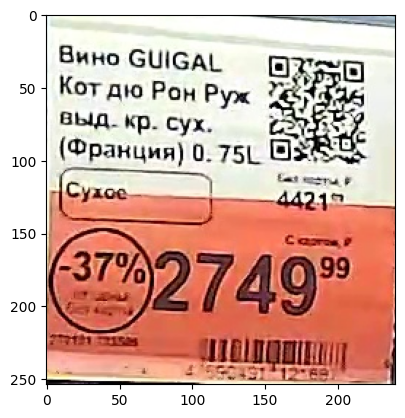

In [149]:
plt.imshow(rotated[:, :, ::-1])

In [151]:
row

filename                                                        26_12-20.mp4
product_name               Вино GUIGAL Кот дю Рон Руж выд. кр. сух. (Фран...
price_default                                                        4421,09
price_card                                                           2749,99
price_discount                                                           нет
barcode                                                      4690491121887.0
discount_amount                                                         -37%
id_sku                                                        270101730056.0
print_datetime                                               17.02.2026 1:14
code                                                                     нет
additional_info                                                        Сухое
color                                                                    red
special_symbols                                                          нет

In [150]:
print(results[0]['rec_texts'])

['Вино (', 'GUIGAL', 'Кот дю Рон Руж', 'выд.', 'kр. cyx.', 'Франция) 0.75L', 'La74', 'Сyxое', '4421', '27', '37%', '2749', '99']
